# Programming exercise 11: Lindblad master equation and Monte Carlo Wave Function Method

## The problem

Light propagating through an atomic medium is usually scattered and thus absorbed by near-resonant coupling to a transition from the ground ($|g_1\rangle$) to an excited ($|e\rangle$) electronic state. If a second light field ("coupling laser") couples the excited state to a third, long-lived state ($|g_2\rangle$), the medium can again become transparent for the first light field ("probe laser"). This effect, called electromagnetically induced transparency (EIT) - the above description referring to the lambda configuration for obvious reasons - has led to a plethora of applications, see e.g. Rev. Mod. Phys. 77, 633 (2005) [1]. The dynamics of the atomic populations can be simulated using the Lindblad master equation approach, accounting for the coherent driving laser fields and incoherent processes such as spontaneous emission and dephasing, e.g. due to finite laser linewidth. The complex refractive index of the atomic medium is given by $n=\sqrt{1+\chi}\approx 1 + (\chi_R + \chi_I)/2$, where the real and imaginary part of the complex susceptibility $\chi$ account for diffraction and absorption of the probe light respectively. $\chi$ depends on the polarizability of the atomic dipoles in the medium and is thus proportional to expectation value of the operator $|g_1\rangle \langle e|$, i.e. $\rm{tr}[|g_1\rangle \langle e| \rho] = \langle e| \rho |g_1 \rangle = \rho_{eg_1}$. This coherence will thus be the main object of interest.

The interaction with the laser fields is described by the Hamiltonian (in rotating wave approximation, in the basis $\{|g_1\rangle,|g_2\rangle,|e\rangle\}$, following the sign convention used in [1])
$$
H=\left[
\begin{array}{ccc}
0 & 0 & -\Omega_p/2 \\
0 & \Delta_p-\Delta_c & -\Omega_c/2 \\
-\Omega_p/2 & -\Omega_c/2 & \Delta_p
\end{array}
\right]
$$

where $\Omega$'s are Rabi-frequencies and $\Delta$'s are the detunings of the lasers from the respective atomic transitions. $\Delta_p-\Delta_c$ is the "two-photon-detuning" sometimes abbreviated as $\delta_2$.

The dissipative processes we want to consider are the spontaneous emission from $e$ to both stable states $g_1$ and $g_2$ and later also the decay from $g_2$ to $g_1$, which destroys the EIT effect. These are accounted for by the jump operators
$$
\Gamma_{eg_1} = \sqrt{\gamma_p} |g_1\rangle \langle e|, \quad \Gamma_{eg_2} = \sqrt{\gamma_c} |g_2\rangle \langle e|, \quad\Gamma_{g_2g_1} = \sqrt{\gamma_g} |g_1\rangle \langle g_2| .
$$
The resulting master equation reads
$$
\dot\rho = -i[H,\rho] + \mathcal{L}_{\Gamma_{eg_1}} [\rho]+ \mathcal{L}_{\Gamma_{eg_2}} [\rho]+ \mathcal{L}_{\Gamma_{g_2g_1}} [\rho]
$$
with the Lindblad superoperator
$$
\mathcal{L}_{\Gamma_x} [\rho] = \Gamma_x \rho \Gamma_x^\dagger - \frac{1}{2}(\Gamma_x^\dagger\Gamma_x \rho + \rho \Gamma_x^\dagger\Gamma_x)
$$

In [1]:
# load standard libraries
import sys
sys.path.append("../src")

import numpy as np   
import numpy.linalg as LA
import matplotlib.pyplot as plt   

import Comp_Quant_Dynam as cqd 

### Exercise 1: System setup and steady state calculation

Construct the Liouvillian superoperator in matrix form and test your implementation by calculating the steady state for the case of zero two-photon detuning ($\delta_2=0$) and $\gamma_g=0$, which is the pure state ("dark state")
$$
|d\rangle = \frac{\Omega_c |g_1\rangle - \Omega_p |g_2\rangle}{\sqrt{\Omega_p^2 + \Omega_c^2}}.
$$

Detailed instructions (You can of course proceed differently if you want. I am pretty sure the method described in the following is not the most elegant one...):
- Building the Liouvillian in matrix form: We want to formulate the master equation in the standard form of an ordinary differential equation $\dot\rho = \mathcal{L} \rho$ with $\rho$ the density matrix in vector form and $\mathcal{L}$ a matrix summarizing the right-hand side of the master equation. However, the master equation is more conveniently formulated using dot-products between matrices representing operators in Hilbert space. Therefore, it makes sense to write a function that takes the vectorized density matrix as an input (along with the Hamiltonian matrix and the jump operators used in the Lindblad terms), converts it into a matrix using reshape(), calculates the right-hand side of the master equation, and returns the result in vector form by using reshape again. To build the Liouvillian matrix you can loop over all the projectors $|i\rangle\langle j|$ passing them to this function. Those are the unit vectors spanning the space of vectorized density matrices. The outputs will be the columns of the Liouvillian matrix.
- Calculating steady states: The steady state is the unique state for which the right-hand side of the master equation gives zero. Calculating this state numerically is less trivial than it seems. If we just try solving the linear system of equations $\mathcal{L}\rho = 0$ it won't work since $\rho=0$ is always a trivial solution. We need to ensure that the trace of the density matrix is 1. This can be achieved by dropping the first line of the master equation ($\dot\rho_{g_1g_1}=...$) and replacing $\rho_{g_1g_1} = 1-\rho_{g_2g_2}-\rho_{ee}$ everywhere. The resulting inhomogeneous system of 8 equations can be solved using np.linalg.solve(). $\rho_{g_1g_1}$ can be prepended to the solution by using the trace condition again. There are many other ways to calculate steady states, see for example the qutip documentation (http://qutip.org/docs/4.0.2/guide/guide-steady.html). You can of course also use qutip routines to check your results.

In [2]:
# Parameters
Omega_p = 1.0
Omega_c = 5.0

# for zero two-photon (detuning=0) means Delta_p = Delta_c
Delta_p = 0.0
Delta_c = 0.0

gamma_p = 1.0
gamma_c = 1.0
gamma_g = 0.0 # for the dark-state 


# Build Hamiltonian and jump operators
H = cqd.utility.lambda_hamiltonian(Omega_p, Omega_c, Delta_p, Delta_c)
jumps = cqd.operators.lambda_jump_operators(gamma_p, gamma_c, gamma_g)

print("Hamiltonian H =\n", H)
print("Jump operators:")
for C in jumps:
    print(C)

Hamiltonian H =
 [[ 0. +0.j  0. +0.j -0.5+0.j]
 [ 0. +0.j  0. +0.j -2.5+0.j]
 [-0.5+0.j -2.5+0.j  0. +0.j]]
Jump operators:
[[0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]]
[[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]]


In [3]:
# Build the Liouvillian

L = cqd.operators.build_liouvillian(H, jumps)
print("Liouvillian shape=", L.shape)

Liouvillian shape= (9, 9)


In [4]:
# Calculate steady state(numerical)

rho_steady = cqd.utility.rho_ss(L)
print("Numerical steady state rho_ss =\n", rho_steady)
print("Trace of rho_ss =", np.trace(rho_steady))

Numerical steady state rho_ss =
 [[ 0.96153846+0.j -0.19230769+0.j  0.        +0.j]
 [-0.19230769+0.j  0.03846154-0.j -0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j]]
Trace of rho_ss = (1+0j)


In [5]:
# Analytical dark state

d = np.array([Omega_c, -Omega_p, 0], dtype=complex)
d = d / np.sqrt(Omega_p**2 + Omega_c**2)
rho_dark = np.outer(d, d.conj())

print("rho_dark =\n", rho_dark)

rho_dark =
 [[ 0.96153846+0.j -0.19230769-0.j  0.        +0.j]
 [-0.19230769+0.j  0.03846154+0.j  0.        +0.j]
 [ 0.        +0.j  0.        -0.j  0.        +0.j]]


In [6]:
# Compare numerical and analytical result

difference = rho_steady - rho_dark
print("Difference=\n", difference)
print("Norm of difference=", LA.norm(difference))
print("Do they match?", np.allclose(rho_steady, rho_dark, atol=1e-10))

Difference=
 [[-1.11022302e-16+0.j  2.77555756e-17+0.j  0.00000000e+00+0.j]
 [ 2.77555756e-17+0.j  0.00000000e+00-0.j -0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]]
Norm of difference= 1.1775693440128312e-16
Do they match? True


### Exercise 2: Physical properties of the steady state

- Scan the probe detuning $\Delta_p$ at resonant coupling beam ($\Delta_c=0$). Plot imaginary and real part of the steady-state value of $\rho_{eg_1}$ as a function of $\Delta_p$. Start with parameters $\Omega_p=\Omega_c=\gamma_p=1$ and all other parameters zero. You should see the charactersitic EIT dip in the absorption (see Fig. 1 in [1]). Then change the coupling Rabi frequency to a larger value to see what happens (Fig. 7 in [1]). Can you interpret the result in the dressed-state picture? Also change $\gamma_p$ and $\gamma_c$ and describe your observations. In principle, $\gamma_p$ can be set to 1, defining the energy scale.
- Now add a spontaneous decay from $g_2$ to $g_1$. Make the same plots again (imaginary part of the steady state $\rho_{eg_1}$, i.e. absorption, as a function of $\Delta_p$) for a fixed value of $\Omega_c=\gamma_p=1$ and various values of $\gamma_{g}$. What do you observe? Compare to Fig. 10 in [1].

Describe and interpret your results.

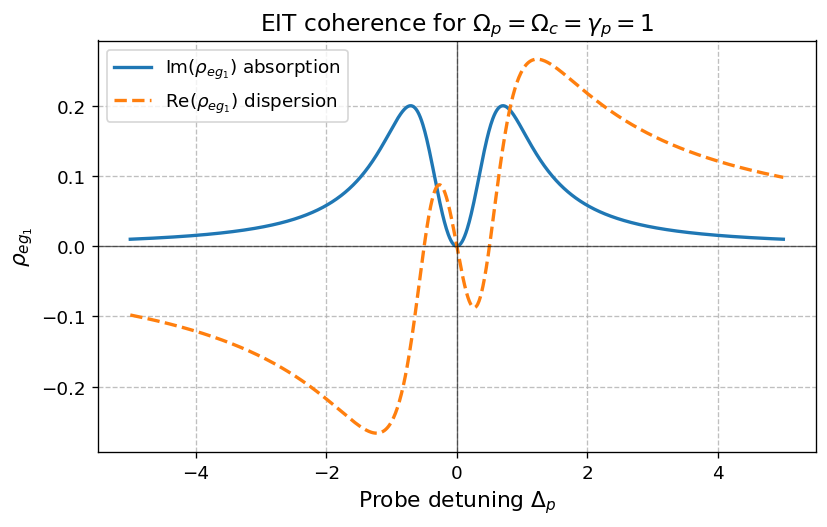

In [7]:
Delta_p_values = np.linspace(-5, 5, 1001)
Omega_p = 1.0
Omega_c = 1.0
Delta_c = 0.0
gamma_p = 1.0
gamma_c = 0.0
gamma_g = 0.0

rho_values = cqd.utility.scan_rho_eg1(Delta_p_values, 1, 1, 0, 1, 0, 0)

# plotting
plt.figure(figsize=(7, 4.5), dpi=120)

plt.plot(Delta_p_values, rho_values.imag, label=r"Im$(\rho_{eg_1})$ absorption", linewidth=2, linestyle="-")
plt.plot(Delta_p_values, rho_values.real, label=r"Re$(\rho_{eg_1})$ dispersion", linewidth=2, linestyle="--")

plt.axhline(0, linewidth=0.8, color="black", alpha=0.6)
plt.axvline(0, linewidth=0.8, color="black", alpha=0.6)
plt.xlabel(r"Probe detuning $\Delta_p$", fontsize=13)
plt.ylabel(r"$\rho_{eg_1}$", fontsize=13)

plt.title(
    r"EIT coherence for $\Omega_p=\Omega_c=\gamma_p=1$",
    fontsize=14
)

plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

For $\Omega_p=\Omega_c=\gamma_p=1$ and all other parameters set to zero, the imaginary part of $\rho_{eg_1}$ shows a dip around $\Delta_p=0$.

This is the characteristic **EIT transparency window**.

At **two-photon resonance**, the atom forms a **dark state**, and the probe absorption is suppressed.

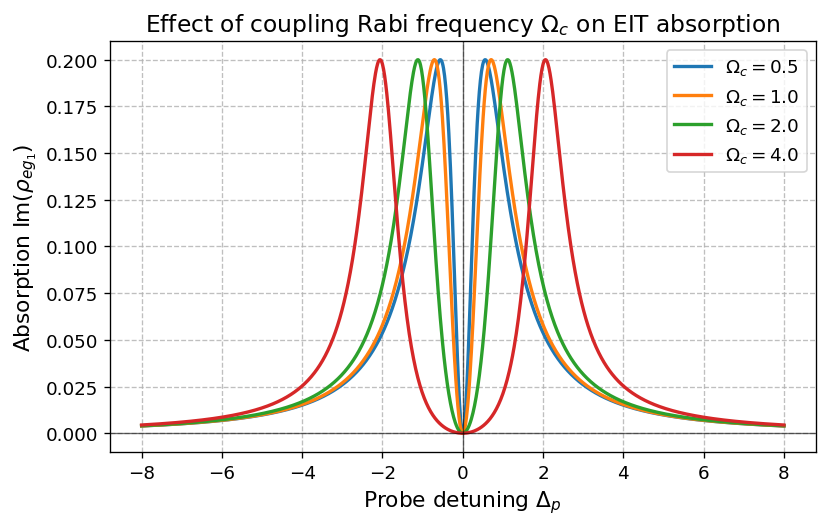

In [8]:
# Effect of coupling Rabi frequency Omega_c

Delta_p_values = np.linspace(-8, 8, 1201)

Omega_p = 1.0
Delta_c = 0.0

gamma_p = 1.0
gamma_c = 0.0
gamma_g = 0.0

Omega_c_values = [0.5, 1.0, 2.0, 4.0]

# plotting the effect of coupling Rabi frequency
plt.figure(figsize=(7, 4.5), dpi=120)

for Omega_c in Omega_c_values:
    rho_values = cqd.utility.scan_rho_eg1(Delta_p_values, 1, Omega_c, 0, 1, 0, 0)
    plt.plot(Delta_p_values,rho_values.imag, linewidth=2, label=fr"$\Omega_c={Omega_c}$")

plt.axhline(0, linewidth=0.8, color="black", alpha=0.6)
plt.axvline(0, linewidth=0.8, color="black", alpha=0.6)
plt.xlabel(r"Probe detuning $\Delta_p$", fontsize=13)
plt.ylabel(r"Absorption Im$(\rho_{eg_1})$", fontsize=13)

plt.title(
    r"Effect of coupling Rabi frequency $\Omega_c$ on EIT absorption",
    fontsize=14
)

plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

Increasing $\Omega_c$ broadens the transparency window.

For larger $\Omega_c$, the absorption profile separates into two side peaks.

In the **dressed-state picture**, the coupling laser mixes $|g_2\rangle$ and $|e\rangle$, producing two dressed states.

The probe then couples to two shifted resonances instead of one central resonance.

This is related to **Autler--Townes splitting**.

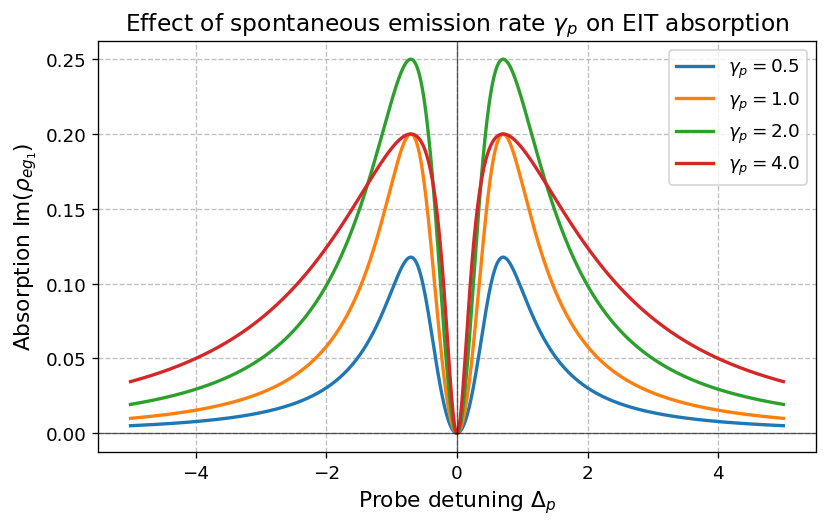

In [9]:
# Effect of gamma_p

Delta_p_values = np.linspace(-5, 5, 1001)
Omega_p = 1.0
Omega_c = 1.0
Delta_c = 0.0
gamma_c = 0.0
gamma_g = 0.0
gamma_p_values = [0.5, 1.0, 2.0, 4.0]

# plotting: effect of spontaneous emission rate
plt.figure(figsize=(7, 4.5), dpi=120)

for gamma_p in gamma_p_values:
    rho_values = cqd.utility.scan_rho_eg1(Delta_p_values, 1, 1, 0, gamma_p, 0, 0)
    plt.plot(Delta_p_values,rho_values.imag,linewidth=2, label=fr"$\gamma_p={gamma_p}$")

plt.axhline(0, linewidth=0.8, color="black", alpha=0.6)
plt.axvline(0, linewidth=0.8, color="black", alpha=0.6)
plt.xlabel(r"Probe detuning $\Delta_p$", fontsize=13)
plt.ylabel(r"Absorption Im$(\rho_{eg_1})$", fontsize=13)

plt.title(
    r"Effect of spontaneous emission rate $\gamma_p$ on EIT absorption",
    fontsize=14
)

plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Changing $\gamma_p$ changes the linewidth and scale of the absorption curve.

A larger $\gamma_p$ gives stronger damping and a broader optical response.

Since $\gamma_p$ defines the natural linewidth, it is convenient to set $\gamma_p=1$ and measure all other frequencies in units of $\gamma_p$.

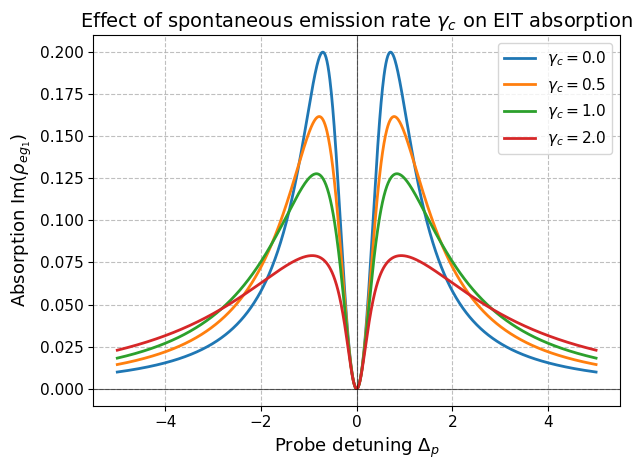

In [10]:
Delta_p_values = np.linspace(-5, 5, 1001)
Omega_p = 1.0
Omega_c = 1.0
Delta_c = 0.0

gamma_p = 1.0
gamma_g = 0.0
gamma_c_values = [0.0, 0.5, 1.0, 2.0]

# plotting spontaneous emission rate gamma_c(change)
for gamma_c in gamma_c_values:
    rho_values = cqd.utility.scan_rho_eg1(Delta_p_values, 1, 1, 0, 1, gamma_c, 0)
    plt.plot(Delta_p_values, rho_values.imag, linewidth=2, label=fr"$\gamma_c={gamma_c}$")
    
plt.axhline(0, linewidth=0.8, color="black", alpha=0.6)
plt.axvline(0, linewidth=0.8, color="black", alpha=0.6)
plt.xlabel(r"Probe detuning $\Delta_p$", fontsize=13)
plt.ylabel(r"Absorption Im$(\rho_{eg_1})$", fontsize=13)
plt.title(r"Effect of spontaneous emission rate $\gamma_c$ on EIT absorption", fontsize=14)
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

Changing $\gamma_c$ modifies the total spontaneous decay from the excited state.

Increasing $\gamma_c$ changes the height and width of the absorption profile.

The decay channels determine how quickly population leaves $|e\rangle$, so they affect the linewidth of the optical response.

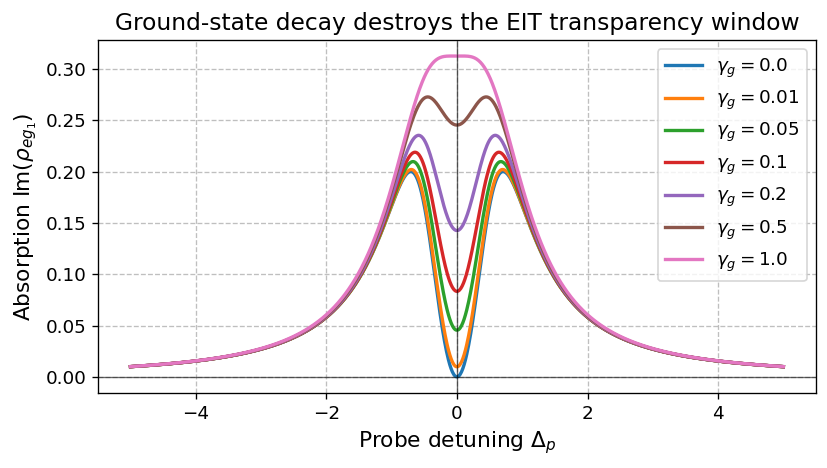

In [11]:
Delta_p_values = np.linspace(-5, 5, 1001)
Omega_p = 1.0
Omega_c = 1.0
Delta_c = 0.0
gamma_p = 1.0
gamma_c = 0.0

# Ground state decay gamma_g
gamma_g_values = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]

# plotting the effect of ground-state decay

plt.figure(figsize=(7, 4), dpi=120)
for gamma_g in gamma_g_values:
    rho_values = cqd.utility.scan_rho_eg1(Delta_p_values, 1, 1, 0, 1, 0, gamma_g)
    plt.plot(Delta_p_values, rho_values.imag, linewidth=2, label=fr"$\gamma_g={gamma_g}$")

plt.axhline(0, linewidth=0.8, color="black", alpha=0.6)
plt.axvline(0, linewidth=0.8, color="black", alpha=0.6)
plt.xlabel(r"Probe detuning $\Delta_p$", fontsize=13)
plt.ylabel(r"Absorption Im$(\rho_{eg_1})$", fontsize=13)
plt.title(r"Ground-state decay destroys the EIT transparency window", fontsize=14)

plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

When $\gamma_g=0$, the system can form a long-lived **dark state**, so the absorption has a strong dip at $\Delta_p=0$.

When $\gamma_g$ increases, population decays from $|g_2\rangle$ to $|g_1\rangle$.

This destroys the **ground-state coherence** required for EIT.

As a result, the transparency dip fills in, and the medium becomes absorbing again near resonance.


I calculated the steady-state coherence $\rho_{eg_1}$, which is proportional to the optical susceptibility of the medium.

The imaginary part gives the **absorption**, and the real part gives the **dispersive response**.

For $\Delta_c=0$, $\Omega_p=\Omega_c=\gamma_p=1$, and all other parameters set to zero, the absorption curve shows a clear **EIT dip** at $\Delta_p=0$.

This happens because, at **two-photon resonance**, the atom enters a **dark state** that does not couple to the excited state.

Increasing the coupling Rabi frequency $\Omega_c$ broadens the **EIT transparency window**.

For large $\Omega_c$, the absorption profile splits into two resonances.

In the **dressed-state picture**, the coupling laser mixes $|g_2\rangle$ and $|e\rangle$, so the probe sees two shifted dressed states.

Changing $\gamma_p$ and $\gamma_c$ changes the linewidth and strength of the absorption.

Since $\gamma_p$ can be used to define the energy scale, it is natural to set $\gamma_p=1$.

Finally, adding ground-state decay $\gamma_g$ from $|g_2\rangle$ to $|g_1\rangle$ destroys the long-lived ground-state coherence.

Therefore, the **EIT dip** becomes weaker and eventually disappears as $\gamma_g$ increases.

### Exercise 3: Dissipative dynamics

Solve the time dependent master equation with initial state $\rho_0 = |g_1\rangle \langle g_1|$. You can use a scipy integrator, for example the one used in exercise sheet 5. Plot the populations of the levels and the real and imaginary part of $\rho_{eg_1}$ as a function of time. Good example parameters are $\Omega_p = 1, \Omega_c = \gamma_p = 2$ and the others zero, integrating to $t=10$. Check qualitatively how the time for approaching the steady state depends on the parameters, especially on $\Omega_c$ and $\Gamma_p$.

In [12]:
Omega_p = 1.0
Omega_c = 2.0

Delta_p = 0.0
Delta_c = 0.0

gamma_p = 2.0
gamma_c = 0.0
gamma_g = 0.0


# Build Hamiltonian
H = cqd.utility.lambda_hamiltonian(1, 2, 0, 0)

# jump operators
jumps = cqd.operators.lambda_jump_operators(2, 0,0)

# Liouvillian
L = cqd.operators.build_liouvillian(H, jumps)
print("Liouvillian shape =", L.shape)

Liouvillian shape = (9, 9)


In [13]:
# Initial state (rho0) = |g1><g1|


rho0 = np.array([
    [1, 0, 0],
    [0, 0, 0],
    [0, 0, 0]
], dtype=complex)

# Time grid
t_eval = np.linspace(0, 10, 1001)

# Solve time-dependent master equation
t_vals, rho_t = cqd.utility.evolve_master_equation(L, rho0, t_eval)
print("rho_t shape =", rho_t.shape)

rho_t shape = (1001, 3, 3)


In [14]:
# Extract populations

pop_g1 = rho_t[:, 0, 0].real
pop_g2 = rho_t[:, 1, 1].real
pop_e  = rho_t[:, 2, 2].real
rho_eg1 = rho_t[:, 2, 0]

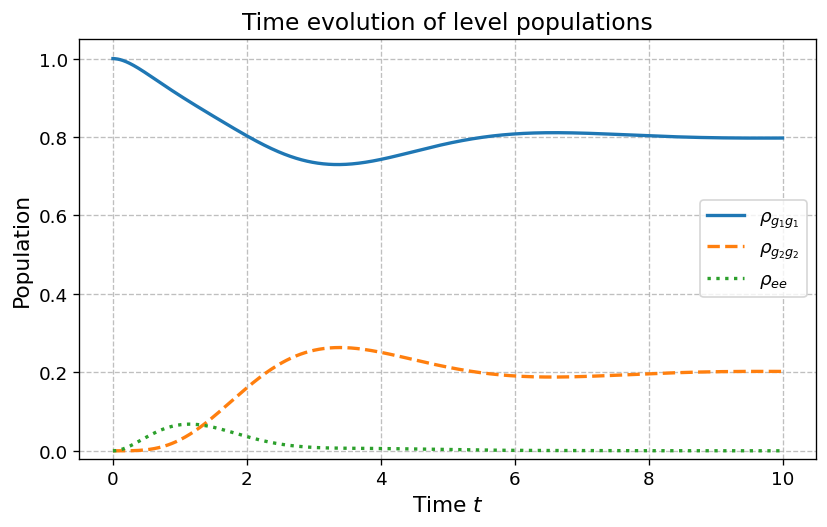

In [15]:
# plotting: time evolution of level populations
plt.figure(figsize=(7, 4.5), dpi=120)

plt.plot(t_vals, pop_g1, linewidth=2, label=r"$\rho_{g_1g_1}$")
plt.plot(t_vals, pop_g2, linewidth=2, linestyle="--", label=r"$\rho_{g_2g_2}$")
plt.plot(t_vals, pop_e, linewidth=2, linestyle=":", label=r"$\rho_{ee}$")

plt.xlabel(r"Time $t$", fontsize=13)
plt.ylabel("Population", fontsize=13)
plt.title("Time evolution of level populations",fontsize=14)

plt.ylim(-0.02, 1.05)
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

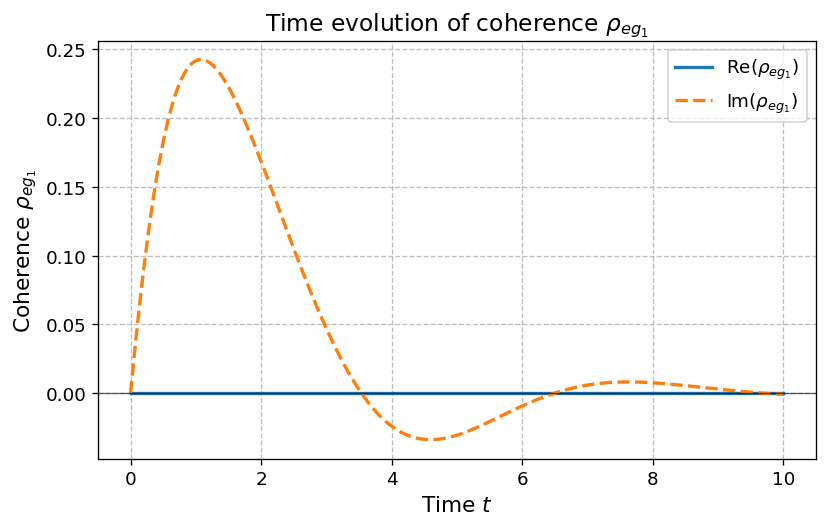

In [16]:

rho_eg1 = rho_t[:, 2, 0]  

# plotting: time evolution of coherence rho_eg1
plt.figure(figsize=(7, 4.5), dpi=120)

plt.plot(t_vals, rho_eg1.real, linewidth=2, label=r"Re$(\rho_{eg_1})$")
plt.plot(t_vals, rho_eg1.imag, linewidth=2, linestyle="--", label=r"Im$(\rho_{eg_1})$")

plt.axhline(0, linewidth=0.8, color="black", alpha=0.6)
plt.xlabel(r"Time $t$", fontsize=13)
plt.ylabel(r"Coherence $\rho_{eg_1}$", fontsize=13)
plt.title(r"Time evolution of coherence $\rho_{eg_1}$",fontsize=14)

plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

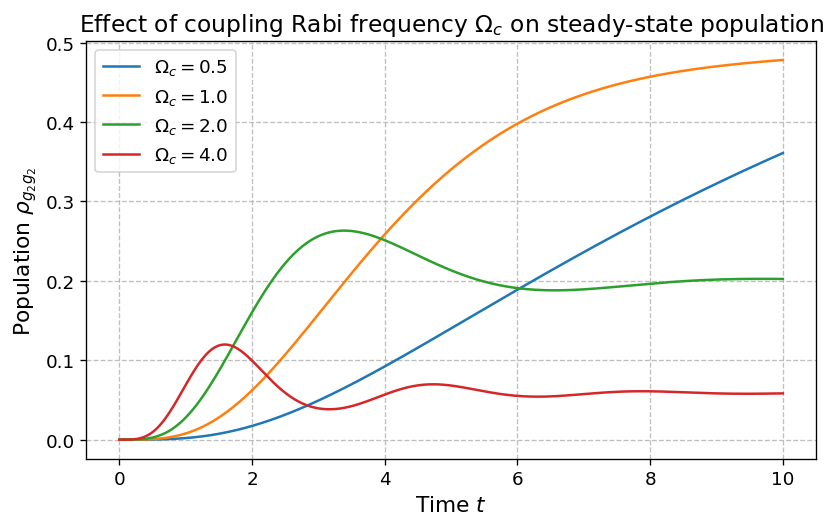

In [17]:
# Check how parameters affect approach to steady state Change Ωc
Omega_c_values = [0.5, 1.0, 2.0, 4.0]

#plotting
plt.figure(figsize=(7, 4.5), dpi=120)
for Omega_c in Omega_c_values:
    H = cqd.utility.lambda_hamiltonian(Omega_p, Omega_c, Delta_p, Delta_c)
    jumps = cqd.operators.lambda_jump_operators(gamma_p, gamma_c, gamma_g)
    L = cqd.operators.build_liouvillian(H, jumps)
    t_vals, rho_t = cqd.utility.evolve_master_equation(L,rho0,t_eval)
    pop_g2 = rho_t[:, 1, 1].real
    plt.plot(t_vals, pop_g2, label=fr"$\Omega_c={Omega_c}$")

plt.xlabel(r"Time $t$", fontsize=13)
plt.ylabel(r"Population $\rho_{g_2g_2}$", fontsize=13)
plt.title(r"Effect of coupling Rabi frequency $\Omega_c$ on steady-state population",fontsize=14)

plt.ylim()
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

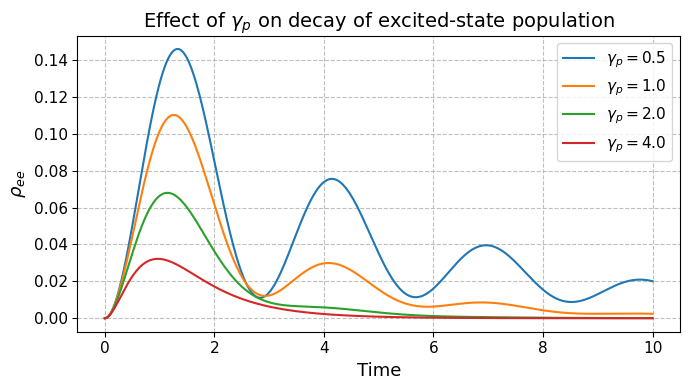

In [18]:
# Check how parameters affect approach to steady state Change γp
gamma_p_values = [0.5, 1.0, 2.0, 4.0]
Omega_c = 2.0

plt.figure(figsize=(7, 4))
for gamma_p in gamma_p_values:
    H = cqd.utility.lambda_hamiltonian(Omega_p, Omega_c, Delta_p, Delta_c)
    jumps = cqd.operators.lambda_jump_operators(gamma_p, gamma_c, gamma_g)
    L = cqd.operators.build_liouvillian(H, jumps)
    t_vals, rho_t = cqd.utility.evolve_master_equation(L, rho0,t_eval)
    pop_e = rho_t[:, 2, 2].real
    plt.plot(t_vals, pop_e, label=fr"$\gamma_p={gamma_p}$")

plt.xlabel("Time", fontsize=13)
plt.ylabel(r"$\rho_{ee}$", fontsize=13)
plt.title(r"Effect of $\gamma_p$ on decay of excited-state population", fontsize=14)
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Starting from the initial state $\rho_0 = |g_1\rangle\langle g_1|$, the laser fields drive population from the ground state $|g_1\rangle$ toward the excited state $|e\rangle$ and the second ground state $|g_2\rangle$.

Because the system is dissipative, the populations and coherences do not oscillate forever. Instead, they approach a steady state.

The excited-state population $\rho_{ee}$ remains relatively small because spontaneous emission removes population from $|e\rangle$.

The coherence $\rho_{eg_1}$ also evolves in time and approaches its steady-state value.

Increasing the coupling Rabi frequency $\Omega_c$ changes the coherent coupling between $|g_2\rangle$ and $|e\rangle$. Larger values of $\Omega_c$ generally produce faster coherent oscillations and change the time scale for reaching the steady state.

Increasing $\gamma_p$ increases the spontaneous emission rate from $|e\rangle$ to $|g_1\rangle$. Stronger dissipation damps the transient oscillations faster, so the system approaches its steady state more quickly.

### Exercise 4: Monte Carlo wave function method

Now we want to solve the dynamics using the Monte Carlo wave function technique. For such a small system (3-dimensional Hilbert space) the method will not be more efficient than directly integrating the master equation. However, when it comes to many-body spin systems, for example, the reduction from a $4^N$ to a $2^N$ dimensional problem at the expense of doing stochastic sampling, can be extremely useful.

First, calculate a single jump trajectory by implementing the algorithm discussed in the lecture (see also Rev. Mod. Phys. 70, 101-144, 1998). Initially the system is in state $|g_1\rangle$.

Try out the following cases: 
- "Standard EIT" case: $\Omega_p=1, \Omega_c=2, \gamma_p=2$ and all other parameters zero. Calculate the evolution up to $t=10$, plotting the populations of the three states. There should not be many jumps in this case. At long times any single trajectory should go to the correct dark state, which you can check using the analytical solution for the dark state. Even if you don't allow any jumps by setting the jump probability to zero, such that you simply propagate with the non-hermitian Hamiltonian and renormalize after each step, you already converge to the correct steady state. (Why?)
- "On-off" case. When $\Omega_p$ and $\Gamma_p$ are much larger than $\Omega_c$ and $\Gamma_c$, we have a situation that is similar to the Dehmelt setup (Phys. Rev. Lett. 57, 1699) with the difference that we have a $\Lambda$-scheme instead of a V-scheme. For the lambda scheme we always have EIT, i.e. the system will end up in the dark state after some time. However, if we add a small decay $\gamma_g$ there is no exact dark state any more and we can observe a similar behavior to the "telegraph noise" reported in Phys. Rev. Lett. 57, 1699, where the atom alternates between a fluorescing state and a dark state. Try the parameters $\Omega_p=1, \Omega_c=0.1, \gamma_p=1, \gamma_c=0.1, \gamma_g=0.01$ and integrate to a long time ($t=1000$).
- Optional: In the V-scheme the difference is that the decay is from the $g$-states to the $e$-state. In this case there is no true dark state. On the other hand, the resulting dynamics we get from the quantum jump simulation is not quite what one expects from the experiment with a single ion. Why is this? What are we missing? If we instead make a ladder scheme with a decay from $g_1$ to $e$ and from $e$ to $g_2$, the telegraph noise behavior is recovered. Try this case with $\Omega_p=1, \Omega_c=0.1, \bar{\gamma}_p=1, \gamma_c=0.1$, where the overbar indicates that the decay goes into the opposite direction compared to the EIT case. Again integrate to a long time.

Secondly, implement the actual Monte Carlo wave function method: Average the observables over many jump trajectories.

To start, try the parameters of the "Standard EIT" case. For 100 jump trajectories and a time step of 0.1 you should already get reasonable results. Compare the result for the populations and the imaginary part of $\rho_{eg_1}$ (absorption) to the direct integration of the master equation from Exercise 3 above.

Also plot ~50 single trajectories (e.g. plotting $\rho_{g_1g_1}$) into one plot to see what the averaging does.

In [19]:
# Standard EIT single trajectory
Omega_p = 1.0
Omega_c = 2.0

Delta_p = 0.0
Delta_c = 0.0

gamma_p = 2.0
gamma_c = 0.0
gamma_g = 0.0

H = cqd.utility.lambda_hamiltonian(1, 2, 0, 0)
jumps = cqd.operators.lambda_jump_operators(2, 0, 0)
psi0 = np.array([1, 0, 0], dtype=complex)
t_eval = np.linspace(0, 10, 1001)
traj = cqd.utility.mcwf_trajectory(H, jumps, psi0, t_eval, seed=1, allow_jumps=True)

print("Number of jumps =", len(traj["jump_times"]))
print("Jump times =", traj["jump_times"])

Number of jumps = 0
Jump times = []


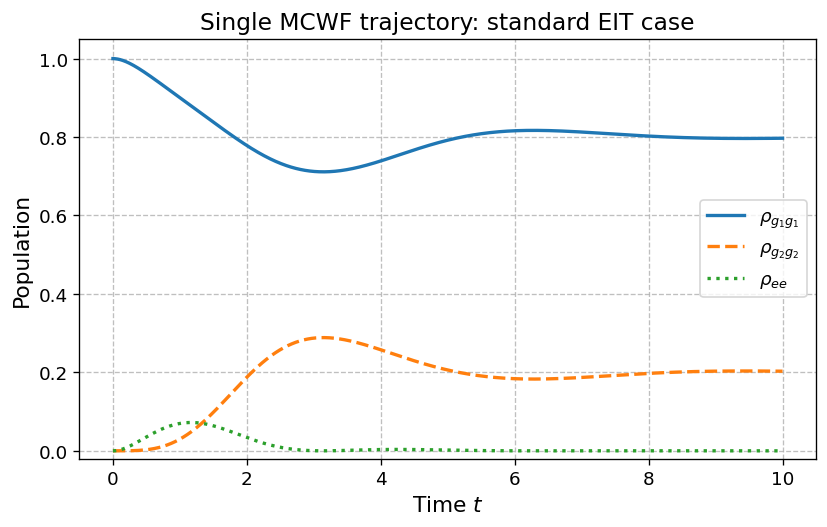

In [20]:
# Plot populations for one MCWF trajectory
pop = traj["populations"]

plt.figure(figsize=(7, 4.5), dpi=120)
plt.plot(t_eval, pop[:, 0], linewidth=2, label=r"$\rho_{g_1g_1}$")
plt.plot(t_eval, pop[:, 1], linewidth=2, linestyle="--", label=r"$\rho_{g_2g_2}$")
plt.plot(t_eval, pop[:, 2], linewidth=2, linestyle=":", label=r"$\rho_{ee}$")

plt.xlabel(r"Time $t$", fontsize=13)
plt.ylabel("Population", fontsize=13)
plt.title("Single MCWF trajectory: standard EIT case", fontsize=14)

plt.ylim(-0.02, 1.05)
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [21]:
# Check dark state

d = np.array([Omega_c, -Omega_p, 0], dtype=complex)

d = d / np.sqrt(Omega_p**2 + Omega_c**2)
dark_pop = np.abs(d)**2

print("Analytical dark-state populations=", dark_pop)
print("Final trajectory populations=", pop[-1])

Analytical dark-state populations= [0.8 0.2 0. ]
Final trajectory populations= [7.96993724e-01 2.03002077e-01 4.19883492e-06]


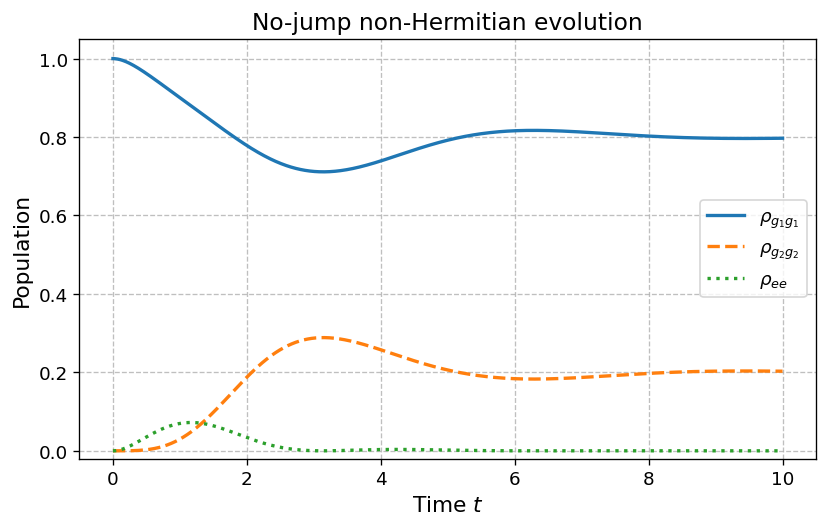

In [22]:
# No-jump evolution

traj_no_jump = cqd.utility.mcwf_trajectory(H, jumps, psi0, t_eval, seed=1, allow_jumps=False)
pop_no_jump = traj_no_jump["populations"]

# plotting, no-jump non-Hermitian evolution

plt.figure(figsize=(7, 4.5), dpi=120)
plt.plot(t_eval, pop_no_jump[:, 0], linewidth=2, label=r"$\rho_{g_1g_1}$")
plt.plot(t_eval, pop_no_jump[:, 1], linewidth=2, linestyle="--", label=r"$\rho_{g_2g_2}$")
plt.plot( t_eval, pop_no_jump[:, 2], linewidth=2, linestyle=":", label=r"$\rho_{ee}$")

plt.xlabel(r"Time $t$", fontsize=13)
plt.ylabel("Population", fontsize=13)
plt.title("No-jump non-Hermitian evolution", fontsize=14)

plt.ylim(-0.02, 1.05)
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [23]:
# Long-time telegraph-like trajectory
Omega_p = 1.0
Omega_c = 0.1

Delta_p = 0.0
Delta_c = 0.0

gamma_p = 1.0
gamma_c = 0.1
gamma_g = 0.01

H = cqd.utility.lambda_hamiltonian(Omega_p, Omega_c, Delta_p, Delta_c)
jumps = cqd.operators.lambda_jump_operators(gamma_p, gamma_c, gamma_g)
psi0 = np.array([1, 0, 0], dtype=complex)

dt = 0.1
t_eval_long = np.arange(0, 1000 + dt, dt)
traj_onoff = cqd.utility.mcwf_trajectory( H, jumps, psi0, t_eval_long, seed=3, allow_jumps=True)
print("Number of jumps =", len(traj_onoff["jump_times"]))

Number of jumps = 143


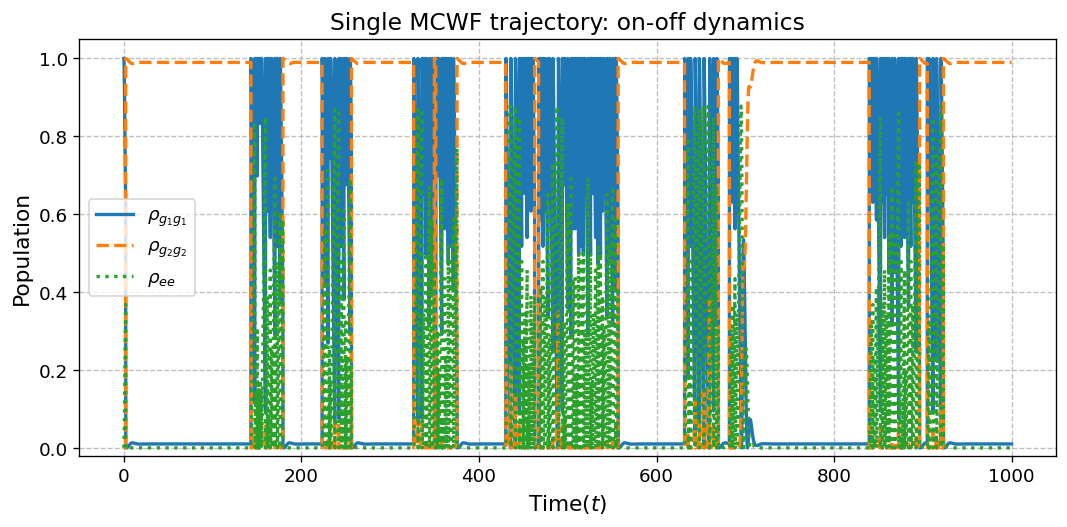

In [24]:
# Plot on-off MCWF trajectory

pop_onoff = traj_onoff["populations"]
plt.figure(figsize=(9, 4.5), dpi=120)

plt.plot(t_eval_long, pop_onoff[:, 0], linewidth=2, label=r"$\rho_{g_1g_1}$")
plt.plot(t_eval_long, pop_onoff[:, 1], linewidth=2, linestyle="--", label=r"$\rho_{g_2g_2}$")
plt.plot(t_eval_long, pop_onoff[:, 2], linewidth=2, linestyle=":", label=r"$\rho_{ee}$")

plt.xlabel(r"Time($t$)", fontsize=13)
plt.ylabel("Population", fontsize=13)
plt.title("Single MCWF trajectory: on-off dynamics",fontsize=14)
plt.ylim(-0.02, 1.05)
plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In the on-off case, the system alternates between bright periods and dark periods. During bright periods, the atom has population in the optically active part of the system and can emit photons. During dark periods, the atom is close to the long-lived dark state and fluorescence is strongly suppressed. The small decay $\gamma_g$ destroys the exact dark state, so the atom can leave the dark period and become bright again.

In [ ]:
# To calculte Monte Carlo average
Omega_p = 1.0
Omega_c = 2.0
Delta_p = 0.0
Delta_c = 0.0
gamma_p = 2.0
gamma_c = 0.0
gamma_g = 0.0

H = cqd.utility.lambda_hamiltonian(1, 2, 0, 0)
jumps = cqd.operators.lambda_jump_operators(2, 0, 0)
L = cqd.operators.build_liouvillian(H, jumps)

psi0 = np.array([1, 0, 0], dtype=complex)
rho0 = np.outer(psi0, np.conj(psi0))
dt = 0.1
t_eval = np.arange(0, 10 + dt, dt)
mcwf_avg = cqd.utility.mcwf_average(H, jumps, psi0, t_eval, ntraj=100, seed=10)

In [ ]:
# Direct master equation comparison

t_direct, rho_direct = cqd.utility.evolve_master_equation(L, rho0, t_eval)

pop_direct = np.zeros((len(t_eval), 3))
pop_direct[:, 0] = rho_direct[:, 0, 0].real
pop_direct[:, 1] = rho_direct[:, 1, 1].real
pop_direct[:, 2] = rho_direct[:, 2, 2].real

rho_eg1_direct = rho_direct[:, 2, 0]

In [ ]:
# Compare populations
pop_avg = mcwf_avg["populations"]

plt.figure(figsize=(8, 4))

plt.plot(t_eval, pop_avg[:, 0], label=r"MCWF $g_1$")
plt.plot(t_eval, pop_avg[:, 1], label=r"MCWF $g_2$")
plt.plot(t_eval, pop_avg[:, 2], label=r"MCWF $e$")

plt.plot(t_eval, pop_direct[:, 0], "--", label=r"Master eq. $g_1$")
plt.plot(t_eval, pop_direct[:, 1], "--", label=r"Master eq. $g_2$")
plt.plot(t_eval, pop_direct[:, 2], "--", label=r"Master eq. $e$")

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("MCWF average compared with Master equation")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.8)
plt.show()

In [ ]:
# Compare absorption of MCWF average vs master equation
rho_eg1_avg = mcwf_avg["rho_eg1"]

plt.figure(figsize=(7, 4.5), dpi=120)
plt.plot(t_eval, rho_eg1_avg.imag, linewidth=2, label=r"MCWF average Im$(\rho_{eg_1})$")
plt.plot(t_eval, rho_eg1_direct.imag, linewidth=2, linestyle="--",  label=r"Master equation Im$(\rho_{eg_1})$")

plt.axhline(0, linewidth=0.8, color="black", alpha=0.6)
plt.xlabel(r"Time $t$", fontsize=13)
plt.ylabel(r"Absorption Im$(\rho_{eg_1})$", fontsize=13)
plt.title(r"Absorption: MCWF average vs Master equation", fontsize=14)

plt.legend(fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

The Monte Carlo wave function method to simulate individual quantum jump trajectories. The effective Hamiltonian is non-Hermitian because it contains the decay terms. Between jumps, the state evolves with this non-Hermitian Hamiltonian and is renormalized. When a jump occurs, one of the jump operators acts on the state.

For the standard EIT case, there are not many jumps. The single trajectory approaches the dark state at long times. Even when jumps are not allowed, the non-Hermitian evolution still drives the system to the dark state because the bright components have excited-state population and are damped away, while the dark state has no excited-state component and therefore does not decay.

In the on-off case, a small decay $\gamma_g$ destroys the exact dark state. The system alternates between bright periods, where it fluoresces, and dark periods, where it is close to the dark state. This produces telegraph-like behavior.

Finally, averaging many Monte Carlo trajectories reproduces the solution of the master equation. Individual trajectories fluctuate strongly, but the average over many trajectories gives the smooth dissipative dynamics of the density matrix.